# 01 - Exploracion multibacteria ARMD V2

Este notebook inicia la V2 con un objetivo **binario**:

- `Susceptible`
- `Resistant`

La clase `Intermediate` se analiza en el conteo general, pero se excluye del dataset de modelado para tener un planteamiento mas claro y estable.


## 1. Configuracion

In [1]:
from pathlib import Path
import csv
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

RUTA_ACTUAL = Path.cwd().resolve()
RUTA_MODELO = None
for candidata in [RUTA_ACTUAL, *RUTA_ACTUAL.parents]:
    if (candidata / "data" / "microbiology_cultures_cohort.csv").exists() and candidata.name.lower() == "modelo":
        RUTA_MODELO = candidata
        break
    if (candidata / "modelo" / "data" / "microbiology_cultures_cohort.csv").exists():
        RUTA_MODELO = candidata / "modelo"
        break
if RUTA_MODELO is None:
    raise FileNotFoundError("No se encontro modelo/data con microbiology_cultures_cohort.csv")

RUTA_DATA = RUTA_MODELO / "data"
RUTA_V2 = RUTA_MODELO / "V2"
RUTA_PROCESADOS = RUTA_V2 / "DATOS_PROCESADOS"
RUTA_GRAFICAS = RUTA_V2 / "GRAFICAS"
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

RUTA_COHORTE = RUTA_DATA / "microbiology_cultures_cohort.csv"
CLASES_VALIDAS_ORIGINALES = {"Susceptible", "Intermediate", "Resistant"}
CLASES_OBJETIVO_V2 = {"Susceptible", "Resistant"}
print(RUTA_COHORTE)


D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\data\microbiology_cultures_cohort.csv


## 2. Conteo de bacterias y clases

In [2]:
conteo_organismo = Counter()
conteo_organismo_valido_original = Counter()
conteo_organismo_binario = Counter()
conteo_clases_por_organismo = defaultdict(Counter)
antibioticos_por_organismo = defaultdict(set)
cultivos_por_organismo = defaultdict(set)
filas_totales = 0

with RUTA_COHORTE.open("r", encoding="utf-8", newline="") as archivo:
    lector = csv.DictReader(archivo)
    for fila in lector:
        filas_totales += 1
        organismo = (fila.get("organism") or "").strip()
        susceptibilidad = (fila.get("susceptibility") or "").strip()
        antibiotico = (fila.get("antibiotic") or "").strip()
        cultivo = (fila.get("culture_description") or "").strip()
        if not organismo:
            continue
        conteo_organismo[organismo] += 1
        if susceptibilidad in CLASES_VALIDAS_ORIGINALES:
            conteo_organismo_valido_original[organismo] += 1
        if susceptibilidad in CLASES_OBJETIVO_V2:
            conteo_organismo_binario[organismo] += 1
            conteo_clases_por_organismo[organismo][susceptibilidad] += 1
            if antibiotico:
                antibioticos_por_organismo[organismo].add(antibiotico)
            if cultivo:
                cultivos_por_organismo[organismo].add(cultivo)

resumen_bacterias = pd.DataFrame({
    "metrica": ["filas_totales", "organismos_distintos_total", "organismos_con_susceptibility_original", "organismos_con_objetivo_binario"],
    "valor": [filas_totales, len(conteo_organismo), len(conteo_organismo_valido_original), len(conteo_organismo_binario)],
})
resumen_bacterias.to_csv(RUTA_PROCESADOS / "00_resumen_cantidad_bacterias.csv", index=False)
resumen_bacterias


,metrica,valor
0,filas_totales,2241050
1,organismos_distintos_total,315
2,organismos_con_susceptibility_original,309
3,organismos_con_objetivo_binario,309


## 3. Organismos candidatos para objetivo binario

In [3]:
registros = []
for organismo, n_validas in conteo_organismo_binario.items():
    clases = conteo_clases_por_organismo[organismo]
    registros.append({
        "organism": organismo,
        "filas_validas_binarias": n_validas,
        "susceptible": clases["Susceptible"],
        "resistant": clases["Resistant"],
        "antibioticos_unicos": len(antibioticos_por_organismo[organismo]),
        "cultivos_unicos": len(cultivos_por_organismo[organismo]),
    })

df_organismos = pd.DataFrame(registros).sort_values("filas_validas_binarias", ascending=False).reset_index(drop=True)
df_organismos["pct_susceptible"] = df_organismos["susceptible"] / df_organismos["filas_validas_binarias"] * 100
df_organismos["pct_resistant"] = df_organismos["resistant"] / df_organismos["filas_validas_binarias"] * 100
df_organismos.to_csv(RUTA_PROCESADOS / "01_resumen_organismos_candidatos.csv", index=False)
df_organismos.head(20)


,organism,filas_validas_binarias,susceptible,resistant,antibioticos_unicos,cultivos_unicos,pct_susceptible,pct_resistant
0,ESCHERICHIA COLI,852148,729553,122595,37,3,85.613415,14.386585
1,KLEBSIELLA PNEUMONIAE,145086,124462,20624,36,3,85.784983,14.215017
2,STAPHYLOCOCCUS AUREUS,81742,63876,17866,23,3,78.143427,21.856573
3,PROTEUS MIRABILIS,66796,55065,11731,34,3,82.437571,17.562429
4,ENTEROCOCCUS SPECIES,62766,50524,12242,17,2,80.495810,19.504190
5,PSEUDOMONAS AERUGINOSA,45480,40020,5460,26,3,87.994723,12.005277
6,MUCOID PSEUDOMONAS AERUGINOSA,30521,25508,5013,21,3,83.575243,16.424757
7,KLEBSIELLA OXYTOCA,24366,21150,3216,31,3,86.801280,13.198720
8,ENTEROBACTER CLOACAE COMPLEX,23072,16840,6232,29,3,72.988904,27.011096
9,COAG NEGATIVE STAPHYLOCOCCUS,20083,11897,8186,19,3,59.239157,40.760843


## 4. Seleccion inicial de organismos V2

In [4]:
ORGANISMOS_V2 = [
    "ESCHERICHIA COLI",
    "KLEBSIELLA PNEUMONIAE",
    "STAPHYLOCOCCUS AUREUS",
    "PROTEUS MIRABILIS",
    "ENTEROCOCCUS SPECIES",
    "PSEUDOMONAS AERUGINOSA",
]

df_organismos_v2 = df_organismos[df_organismos["organism"].isin(ORGANISMOS_V2)].copy()
df_organismos_v2.to_csv(RUTA_PROCESADOS / "02_organismos_seleccionados_v2.csv", index=False)

df_decision = pd.DataFrame({"organism": ORGANISMOS_V2, "decision": "usar_v2_binario", "motivo": "organismo frecuente con volumen suficiente para Susceptible vs Resistant"})
df_decision.to_csv(RUTA_PROCESADOS / "03_decision_organismos_v2.csv", index=False)
df_organismos_v2


,organism,filas_validas_binarias,susceptible,resistant,antibioticos_unicos,cultivos_unicos,pct_susceptible,pct_resistant
0,ESCHERICHIA COLI,852148,729553,122595,37,3,85.613415,14.386585
1,KLEBSIELLA PNEUMONIAE,145086,124462,20624,36,3,85.784983,14.215017
2,STAPHYLOCOCCUS AUREUS,81742,63876,17866,23,3,78.143427,21.856573
3,PROTEUS MIRABILIS,66796,55065,11731,34,3,82.437571,17.562429
4,ENTEROCOCCUS SPECIES,62766,50524,12242,17,2,80.495810,19.504190
5,PSEUDOMONAS AERUGINOSA,45480,40020,5460,26,3,87.994723,12.005277


## 5. Graficas iniciales

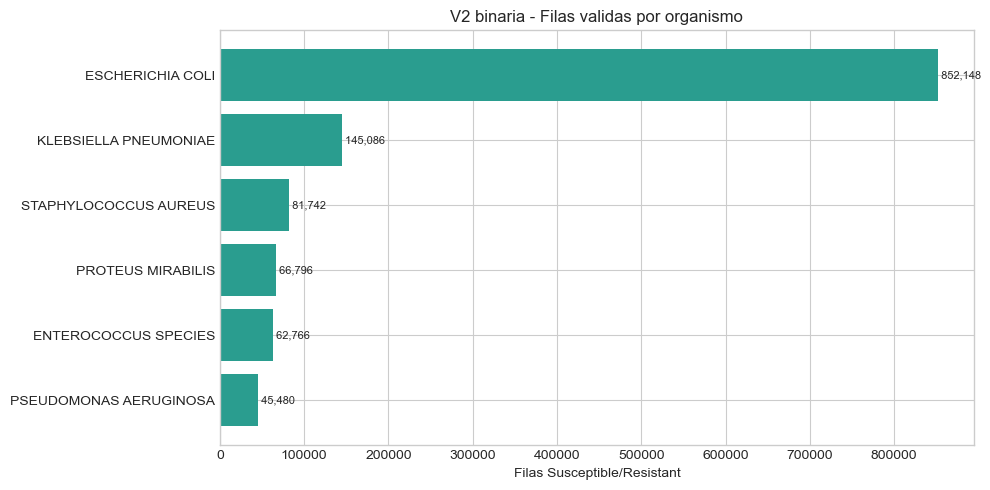

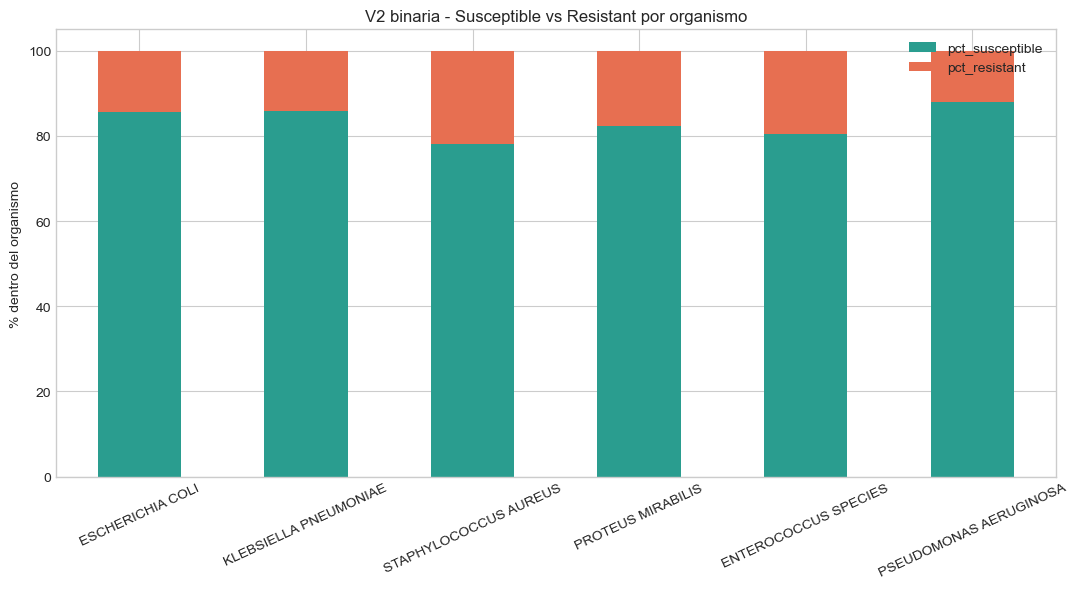

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_organismos_v2.sort_values("filas_validas_binarias", ascending=True)
ax.barh(df_plot["organism"], df_plot["filas_validas_binarias"], color="#2a9d8f")
ax.set_title("V2 binaria - Filas validas por organismo")
ax.set_xlabel("Filas Susceptible/Resistant")
for i, valor in enumerate(df_plot["filas_validas_binarias"]):
    ax.text(valor, i, f" {valor:,}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS / "01_v2_binario_filas_validas_por_organismo.png", dpi=220, bbox_inches="tight")
plt.show()

tabla = df_organismos_v2.set_index("organism")[["pct_susceptible", "pct_resistant"]].loc[ORGANISMOS_V2]
fig, ax = plt.subplots(figsize=(11, 6))
tabla.plot(kind="bar", stacked=True, ax=ax, color=["#2a9d8f", "#e76f51"])
ax.set_title("V2 binaria - Susceptible vs Resistant por organismo")
ax.set_ylabel("% dentro del organismo")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS / "02_v2_binario_susceptibility_por_organismo.png", dpi=220, bbox_inches="tight")
plt.show()


## 6. Conclusion

V2 queda definida como clasificacion binaria: `Susceptible` vs `Resistant`. La clase `Intermediate` se excluye para evitar inestabilidad por baja frecuencia y ambiguedad clinica en esta etapa.
